# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset yang digunakan adalah Food Delivery Dataset yang menyimulasikan operasional pengiriman makanan. Dataset ini dipilih karena sangat relevan dengan industri lokal dan memiliki tantangan dunia nyata seperti data kosong (missing values) serta tipe data campuran (kategorikal dan numerikal).
Tujuan dari eksperimen ini adalah memprediksi status pesanan (misalnya: Completed atau Cancelled) berdasarkan fitur seperti jarak, waktu, dan cuaca.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
#Type your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
import joblib # Untuk menyimpan objek scaler/encoder nantinya

# Pengaturan visualisasi
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
#Type your code here
file_path = 'synthetic_fooddelivery_dataset.csv'
df = pd.read_csv(file_path)

print("Ukuran dataset:", df.shape)
display(df.head())

Ukuran dataset: (8500, 11)


,ID_Pesanan,Waktu_Transaksi,Kategori_Menu,Harga_Pesanan,Jarak_Kirim_KM,Waktu_Tunggu_Menit,Rating_Pelanggan,Ulasan_Teks,Status_Promo,Tingkat_Keluhan,Status_Pesanan
0,ORD-2024-000001,2024-03-22 13:15:14,Kopi,9000,NaN,27,4.0,Sesuai pesanan,False,Tidak Ada,Selesai
1,ORD-2024-000002,2024-01-14 17:05:37,Mie,21000,3.742238,37,NaN,NaN,False,Tidak Ada,Selesai
2,ORD-2024-000003,2024-01-04 12:32:38,Martabak,33500,12.677149,49,NaN,NaN,True,Rendah,Selesai
3,ORD-2024-000004,2024-01-26 22:34:26,Kopi,13500,2.338085,20,5.0,Mantap gan!,False,Tidak Ada,Selesai
4,ORD-2024-000005,2024-03-16 11:48:51,Ayam,47500,0.949764,27,4.0,Top bgt kualitasnya,True,Rendah,Selesai


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

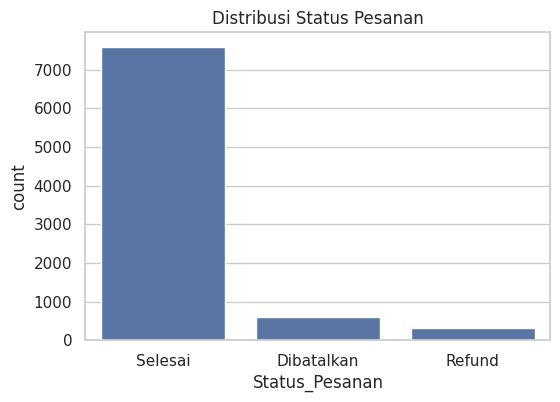

In [5]:
# 3. Visualisasi Distribusi Target
target_col = 'Status_Pesanan'

if target_col in df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=target_col)
    plt.title('Distribusi Status Pesanan')
    plt.show()
else:
    print(f"Kolom {target_col} tidak ditemukan. Silakan sesuaikan nama kolomnya.")

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [6]:
# Menentukan pembagian kolom berdasarkan tipe datanya
target_col = 'Status_Pesanan'
kolom_numerikal = ['Harga_Pesanan', 'Jarak_Kirim_KM', 'Waktu_Tunggu_Menit', 'Rating_Pelanggan']
kolom_kategorikal = ['Kategori_Menu', 'Status_Promo', 'Tingkat_Keluhan']
kolom_buang = ['ID_Pesanan', 'Waktu_Transaksi', 'Ulasan_Teks']

# Memastikan dataset tidak berantakan, kita copy dataframe
df_clean = df.copy()

# 1. Menghapus kolom yang tidak relevan untuk ML tabular (ID dan Teks deskriptif)
df_clean = df_clean.drop(columns=[col for col in kolom_buang if col in df_clean.columns])

# 2. Menangani Missing Values
# Mengisi angka kosong dengan median, dan kategori kosong dengan modus
imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')

df_clean[kolom_numerikal] = imputer_num.fit_transform(df_clean[kolom_numerikal])
df_clean[kolom_kategorikal] = imputer_cat.fit_transform(df_clean[kolom_kategorikal])

# 3. Encoding Data Kategorikal
# Mengubah teks kategori menjadi kolom numerik (0 dan 1)
df_clean = pd.get_dummies(df_clean, columns=kolom_kategorikal, drop_first=True)

# Label Encoding untuk Target (mengubah misal 'Completed'/'Cancelled' jadi 0/1)
le = LabelEncoder()
df_clean[target_col] = le.fit_transform(df_clean[target_col])

# 4. Normalisasi / Standarisasi Fitur Numerik
# Menyamakan skala jarak, harga, menit, dan rating agar model tidak bias
scaler = StandardScaler()
df_clean[kolom_numerikal] = scaler.fit_transform(df_clean[kolom_numerikal])

# 5. Memisahkan Fitur (X) dan Target (y)
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

print("Data siap! Ukuran X:", X.shape, "Ukuran y:", y.shape)
display(X.head())

# (Opsional) Menyimpan data yang sudah bersih untuk di-cek
# df_clean.to_csv("food_delivery_cleaned.csv", index=False)

Data siap! Ukuran X: (8500, 10) Ukuran y: (8500,)


,Harga_Pesanan,Jarak_Kirim_KM,Waktu_Tunggu_Menit,Rating_Pelanggan,Kategori_Menu_Kopi,Kategori_Menu_Martabak,Kategori_Menu_Mie,Status_Promo_True,Tingkat_Keluhan_Tidak Ada,Tingkat_Keluhan_Tinggi
0,-0.181250,-0.303726,0.319033,-0.154368,True,False,False,False,True,False
1,-0.160431,0.244398,1.060442,-0.154368,False,False,True,False,True,False
2,-0.138745,3.304713,1.950134,-0.154368,False,True,False,True,False,False
3,-0.173443,-0.236541,-0.199954,0.946412,True,False,False,False,True,False
4,-0.114457,-0.712058,0.319033,-0.154368,False,False,False,True,False,False
